# LLM basics — your first API calls

This notebook is where the room finally *does* what the slides described: you send real prompts to a real model, watch the parameters change the answer, open up a small model to see how the next token is picked, count the tokens you pay for, try three prompt engineering techniques on one claim note, and make the limitations show themselves.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/01_llm_basics/01_llm_basics.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

It assumes only notebook 00: how to run a cell, and how to put your key in place. Like every notebook in this series, it **ships with its outputs**, so you can read every answer the model actually gave before you run a single cell yourself. Section 3 runs a small open model, GPT-2, on the machine the notebook runs on: it needs no key, but the first time you run it, it downloads about 551 MB.

## Learning objectives

After working through this notebook you will be able to:

- **send** a prompt to a model from Python and read the answer back;
- **steer** an answer with `instructions` and cap it with `max_output_tokens`;
- **explain** what greedy decoding, temperature and top-p do to a next-token distribution, having watched them on GPT-2 small, and why the API calls here leave `temperature` and `top_p` alone;
- **count** the tokens in an actuarial sentence and **price** a real call from the provider's list price;
- **compare** zero-shot, few-shot and chain-of-thought prompting on one real claim note;
- **demonstrate** hallucination, prompt sensitivity and the training cut-off rather than taking them on trust.

## Contents

1. [Setup](#1-setup)
2. [Your first call, and the parameters you control](#2-your-first-call-and-the-parameters-you-control)
3. [Inside the model: how the next token is chosen](#3-inside-the-model-how-the-next-token-is-chosen)
4. [Tokens and cost, made visible](#4-tokens-and-cost-made-visible)
5. [Prompt engineering on one claim note](#5-prompt-engineering-on-one-claim-note)
6. [Limitations, demonstrated rather than asserted](#6-limitations-demonstrated-rather-than-asserted)
7. [Summary and what comes next](#7-summary-and-what-comes-next)

---

## 1 Setup

One cell, run once. It fixes the model, records the prices we will use for costing, finds your key without ever printing it, and defines the single helper `ask()` that every later API call goes through.

`ask()` is deliberately tiny. It wraps one call to `client.responses.create(...)` and hands back the text, so that from here on you read *what we asked*, never the plumbing around it. It keeps the full reply in `last_response` as well, because section 4 needs the token counts out of it.

In [1]:
import os

import tiktoken
from openai import OpenAI

# The model this seminar is pinned to. Pinning the exact dated version means the
# notebook answers the same way in October as it did when it was written.
MODEL = "gpt-5.4-nano-2026-03-17"

# List price as of 15 September 2026, in US dollars per million tokens.
PRICE_IN_USD_PER_MTOK = 0.20   # what you pay for what you send
PRICE_OUT_USD_PER_MTOK = 1.25  # what you pay for what comes back


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
client = OpenAI(api_key=key) if key else None

last_response = None  # the full reply of the most recent ask(); section 4 reads its usage


def ask(prompt, instructions=None, max_output_tokens=None):
    """Send one prompt to the model and return its answer as plain text."""
    global last_response
    if client is None:
        raise RuntimeError("No OPENAI_API_KEY is visible - see notebook 00, section 6.")
    options = {}
    if instructions is not None:
        options["instructions"] = instructions
    if max_output_tokens is not None:
        options["max_output_tokens"] = max_output_tokens
    last_response = client.responses.create(model=MODEL, input=prompt, **options)
    return (last_response.output_text or "").strip()


if key:
    print(f"[PASS] A key named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No key named OPENAI_API_KEY is visible to this notebook.")
    print("            Every cell that calls the API needs one; section 3 (GPT-2) needs none. Notebook 00, section 6 explains how.")

print(f"Model  : {MODEL}")
print(f"Prices : USD {PRICE_IN_USD_PER_MTOK} in / USD {PRICE_OUT_USD_PER_MTOK} out per 1M tokens")
print("         (list price as of 15 September 2026)")

[PASS] A key named OPENAI_API_KEY is visible (164 characters long).
       Its value is never printed - not here, not anywhere.
Model  : gpt-5.4-nano-2026-03-17
Prices : USD 0.2 in / USD 1.25 out per 1M tokens
         (list price as of 15 September 2026)


---

## 2 Your first call, and the parameters you control

### Why it matters for actuaries

The web chat window is somebody else's prompt plus your question. The API is *your* prompt, in *your* code, on *your* data, with the parameters written down where a reviewer can see them. Everything an actuary needs from a model — repeatability, an audit trail, a documented setup — starts here.

The simplest possible call: one question, nothing else.

In [2]:
QUESTION = "What is the Solvency Capital Requirement?"

print(ask(QUESTION))

The **Solvency Capital Requirement (SCR)** is the **minimum amount of capital (funds)** that an insurance or reinsurance firm must hold under the **Solvency II** framework in order to ensure it can withstand a **specified level of loss** over a given time horizon.

- **Purpose:** measures the firm’s required “buffer” against unexpected losses.  
- **How it’s set:** based on a **risk-based calculation** that reflects the firm’s underwriting, market, credit, operational, and other risks.  
- **Confidence level / risk tolerance:** designed so that the firm can meet obligations with a probability corresponding to roughly a **99.5% confidence level** over **one year** (i.e., a typical target is that the chance of insolvency is about 0.5% over 12 months).  
- **Regulatory use:** regulators check whether the firm has enough eligible own funds to cover the SCR. If not, the firm may be required to take corrective actions.

If you tell me your context (e.g., Solvency II in the EU/UK, or another 

### The same question, two different audiences

`instructions` is the standing brief that sits above your prompt — the role, the tone, the length. The question below does not change at all; only the brief does. Watch what happens to the answer.

In [3]:
for brief in [
    "Answer in one sentence for a board member.",
    "Answer for a fellow actuary.",
]:
    print(f"--- instructions: {brief}")
    print(ask(QUESTION, instructions=brief))
    print()

--- instructions: Answer in one sentence for a board member.


The Solvency Capital Requirement (SCR) is the regulatory amount of capital an insurer must hold to absorb significant losses over a one‑year period with a prescribed confidence level, ensuring it can meet policyholder obligations under adverse conditions.

--- instructions: Answer for a fellow actuary.


The **Solvency Capital Requirement (SCR)** is the **capital amount an (insurance) firm must hold to ensure it can absorb significant losses** over a specified time horizon (typically **one year**) with a high level of confidence.

In practice, under **Solvency II (EU)**, the SCR is defined as the capital needed so that the firm can meet its obligations over the next 12 months with probability equivalent to a **99.5% confidence level** (i.e., a **Value-at-Risk** style requirement).

So, in short: **SCR = required own funds to withstand a severe loss scenario with ~99.5% confidence over 1 year**, ensuring policyholder protection.

If you tell me whether you mean **Solvency II specifically** or the broader actuarial concept, I can tailor the wording to the exact regulatory definition you need.



Same model, same question, same price list — a different reader. The board brief came back as a single sentence; the actuarial brief came back structured, reached for Value-at-Risk and the 99.5% one-year calibration, and offered to narrow further. The call before it, with no brief at all, answered at length with headings because nothing told it who was asking.

`instructions` is therefore the cheapest quality control you have. Write it down, keep it with the code, and a reviewer can see exactly what the model was told.

### Capping the length with `max_output_tokens`

`max_output_tokens` is a hard ceiling on what comes back. It is a cost control, not a style control: the model is not asked to be brief, it is simply cut off when it reaches the limit. The cell below sets a ceiling of 16 tokens so that you can see exactly that.

In [4]:
short = ask(QUESTION, max_output_tokens=16)

print(short)
print()
print(f"status: {last_response.status}")
print(f"reason: {last_response.incomplete_details}")

The **Solvency Capital Requirement (SCR)** is the amount

status: incomplete
reason: IncompleteDetails(reason='max_output_tokens')


The answer stops mid-sentence, at "is the amount". The model was not being concise; it was cut off, and `status` says so: `incomplete`, because of `max_output_tokens`.

That matters in production, because a truncated answer looks exactly like a finished one. If you cap the length, check the status.

### A note on `temperature` and `top_p`

Two parameters you have probably heard of are **deliberately absent from every API call in this notebook**: `temperature` and `top_p`. Whether a model accepts them depends on the model and on its reasoning effort. The GPT-5.4 models accept them only at reasoning effort `none`, which is their default setting; ask one of them to reason and it rejects both with an error. GPT-6 Luna, which several case studies use, accepts `temperature` only at effort `none` and rejects it at its default effort, `medium`. Where a model accepts it, the case studies set `temperature` to 0 to make answers more repeatable. Here we leave both alone: if you want a shorter, blander or more adventurous answer, you ask for it in `instructions` — you do not turn a dial.

What the two dials do is easiest to see on a model you can open up. That is the next section.

---

## 3 Inside the model: how the next token is chosen

### Why it matters for actuaries

Every answer above was written one token at a time. The model gives every token in its vocabulary a score, turns the scores into probabilities, picks one token, appends it and starts again. `temperature` and `top_p` act on the *picking* step, which a hosted model runs on the provider's side, out of sight. Knowing what they do, and what they cannot do, is what lets you judge a claim such as "we set the temperature to zero, so the answers are reliable".

So we open up a model small enough to run on the machine this notebook runs on, and turn the dials by hand. The model is **GPT-2 small** (`gpt2` on Hugging Face): 124 million parameters, released by OpenAI in 2019 under the MIT licence, and built on the same idea as today's frontier models — a transformer trained to predict the next token. Its writing is poor by 2026 standards, and that is the point: this section shows the *mechanism*, not capability. It is a teaching toy, not a production local stack; the slide "Cloud vs. Local" covers real local deployment.

The section needs no key and sends nothing to a provider. It does need `torch` and `transformers`: Colab ships both, and locally they are in `requirements.txt`. The first time you run it, it downloads about 551 MB from Hugging Face, almost all of it model weights, into a local cache (on Colab, onto the temporary machine); later runs read them from there. On Colab a notice that `HF_TOKEN` is not set may appear: GPT-2 is public, so no token is needed.

The first cell checks for the two packages. If either is missing, it says so, and every GPT-2 cell below skips itself instead of failing; the rest of the notebook does not depend on this section.

In [5]:
# GPT-2 runs on this machine through torch and transformers. Colab ships both; locally they are
# pinned in requirements.txt. If either is missing, the GPT-2 cells below skip themselves.
import time

try:
    import matplotlib.pyplot as plt
    import torch
    import transformers
    from matplotlib.patches import Patch
    from matplotlib.ticker import PercentFormatter
    from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
    from transformers.utils import logging as hf_logging

    GPT2_READY = True
    print(f"[PASS] torch {torch.__version__} and transformers {transformers.__version__} are available.")
except (ImportError, OSError):  # OSError: a torch installation that cannot load its own libraries
    GPT2_READY = False
    print("[ATTENTION] torch or transformers cannot be imported, so the GPT-2 cells of this section are skipped.")
    print("            Colab ships both; locally, pip install them at the versions in requirements.txt.")

GPT2_IMPORTED = GPT2_READY  # the next code cell loads GPT-2 only if both packages could be imported
SKIPPED = "[ATTENTION] Skipped: GPT-2 is not available here - see the first two code cells of section 3."
NAVY, GREY = "#1F3A6E", "#CCCCCC"  # the colours of the slides

[PASS] torch 2.7.0+cpu and transformers 4.48.2 are available.


Now the model itself. The next cell loads GPT-2 and prints the numbers behind the slide "How an LLM Works — One Token at a Time": the vocabulary a text is cut into, the length of the vector that represents each token, and the attention heads through which each token reads the ones before it. It also fixes the seed that section 3.4 samples with.

In [6]:
if not GPT2_IMPORTED:
    print(SKIPPED)
else:
    hf_logging.set_verbosity_error()  # keep the library's housekeeping notices out of the output
    hf_logging.disable_progress_bar()

    GPT2 = "gpt2"  # GPT-2 small; its model card on Hugging Face is openai-community/gpt2
    SEED = 42

    started = time.time()
    try:
        gpt2_tokenizer = AutoTokenizer.from_pretrained(GPT2)
        gpt2 = AutoModelForCausalLM.from_pretrained(GPT2)  # on the CPU
    except Exception as problem:  # typically a first run without a connection: nothing to load yet
        GPT2_READY = False
        print(f"[ATTENTION] GPT-2 could not be loaded ({type(problem).__name__}), so the cells below are skipped.")
        print("            A first run downloads about 551 MB - check the connection, then run the cell again.")
    else:
        GPT2_READY = True
        gpt2.eval()  # inference only: switches dropout off
        config = gpt2.config
        print(f"[PASS] Loaded {GPT2} in {time.time() - started:.1f} seconds.")
        print(f"Parameters : {sum(p.numel() for p in gpt2.parameters()):,}")
        print(f"Vocabulary : {config.vocab_size:,} tokens")
        print(f"Embeddings : {config.n_embd} numbers per token")
        layers, heads = config.n_layer, config.n_head
        print(f"Attention  : {layers} layers x {heads} heads = {layers * heads} heads")
        print(f"Context    : at most {config.n_positions:,} tokens")

[PASS] Loaded gpt2 in 1.5 seconds.
Parameters : 124,439,808
Vocabulary : 50,257 tokens
Embeddings : 768 numbers per token
Attention  : 12 layers x 12 heads = 144 heads
Context    : at most 1,024 tokens


### 3.1 One forward pass: a probability for every token

We give GPT-2 the start of the sentence on the slide "Example of Next Token Prediction" and ask for its scores for the token that comes next. One pass through the network returns a score for every token in the vocabulary, and the softmax turns the scores into probabilities that add up to one.

Prompt : 'The Solvency Capital Requirement is'
Tokens : The |  Sol | ven | cy |  Capital |  Requ | irement |  is  (8 tokens)
Output : one score for each of the 50,257 tokens in the vocabulary

The ten most likely next tokens:
   1. ' a'         11.1%
   2. ' the'        6.5%
   3. ' to'         4.4%
   4. ' not'        4.3%
   5. ' that'       4.1%
   6. ' an'         3.5%
   7. ' $'          2.3%
   8. ' required'   2.2%
   9. ' one'        1.7%
  10. ' for'        1.2%

Together they hold 41.4% of the probability; the other 50,247 tokens share the rest.


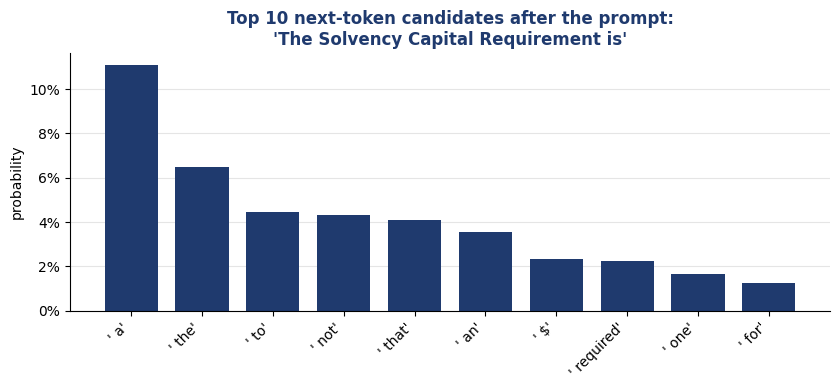

In [7]:
if not GPT2_READY:
    print(SKIPPED)
else:
    PROMPT = "The Solvency Capital Requirement is"

    input_ids = gpt2_tokenizer(PROMPT, return_tensors="pt").input_ids
    with torch.no_grad():  # no training here, so no gradients
        logits = gpt2(input_ids).logits[0, -1, :]  # the scores for the token after the last one

    probabilities = torch.softmax(logits, dim=-1)
    top10_p, top10_ids = torch.topk(probabilities, 10)
    top10_tokens = [gpt2_tokenizer.decode([i]) for i in top10_ids.tolist()]

    prompt_tokens = [gpt2_tokenizer.decode([i]) for i in input_ids[0].tolist()]
    print(f"Prompt : {PROMPT!r}")
    print(f"Tokens : {' | '.join(prompt_tokens)}  ({len(prompt_tokens)} tokens)")
    print(f"Output : one score for each of the {logits.shape[0]:,} tokens in the vocabulary")
    print()
    print("The ten most likely next tokens:")
    for rank, (token, p) in enumerate(zip(top10_tokens, top10_p.tolist()), start=1):
        print(f"{rank:>4}. {token!r:<12}{p:>6.1%}")
    print()
    print(f"Together they hold {top10_p.sum().item():.1%} of the probability; "
          f"the other {logits.shape[0] - 10:,} tokens share the rest.")

    def plot_top10(colours, title):
        """Bar chart of the ten most likely next tokens after PROMPT."""
        fig, ax = plt.subplots(figsize=(8.5, 4))
        ax.bar(range(10), top10_p.numpy(), color=colours, width=0.75)
        ax.set_xticks(range(10), [repr(t) for t in top10_tokens], rotation=45, ha="right")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax.set_ylabel("probability")
        ax.set_title(title, color=NAVY, fontweight="bold")
        ax.grid(axis="y", color="#E5E5E5")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        return fig, ax

    fig, ax = plot_top10(NAVY, f"Top 10 next-token candidates after the prompt:\n{PROMPT!r}")
    fig.tight_layout()
    plt.show()

GPT-2 cuts the prompt into eight tokens: "Solvency" becomes three of them (`Sol`, `ven`, `cy`) and "Requirement" two (`Requ`, `irement`). The favourite next token, `' a'`, gets only 11.1%. The favourites are grammatical glue — `' a'`, `' the'`, `' to'`, `' not'` — and GPT-2, which does not know what the Solvency Capital Requirement is, spreads its bets thinly: the ten favourites together hold 41.4% of the probability; the other 50,247 tokens share the rest. Everything a picking rule does, it does to this distribution.

### 3.2 Temperature: sharpen or flatten

Temperature divides every score by a number *T* before the softmax: $p_i \propto \exp(\text{logit}_i / T)$. Below 1 it sharpens the distribution, above 1 it flattens it. The table applies four temperatures to the same scores and shows what happens to the five favourites and to the top ten together.

In [8]:
if not GPT2_READY:
    print(SKIPPED)
else:
    print(f"{'':<10}" + "".join(f"{t!r:>9}" for t in top10_tokens[:5]) + "   top 10 together")
    for temperature in [0.1, 0.5, 1.0, 1.5]:
        reshaped = torch.softmax(logits / temperature, dim=-1)  # the same scores, divided by T
        shares = "".join(f"{reshaped[i].item():>9.1%}" for i in top10_ids[:5].tolist())
        print(f"T = {temperature:<6}{shares}{reshaped[top10_ids].sum().item():>18.1%}")

               ' a'   ' the'    ' to'   ' not'  ' that'   top 10 together
T = 0.1       99.5%     0.5%     0.0%     0.0%     0.0%            100.0%
T = 0.5       47.2%    16.2%     7.6%     7.2%     6.4%             95.1%
T = 1.0       11.1%     6.5%     4.4%     4.3%     4.1%             41.4%
T = 1.5        2.1%     1.4%     1.1%     1.1%     1.1%             10.3%


At T = 1.0 the table repeats the raw distribution. At T = 0.5 the favourite rises from 11.1% to 47.2% and the top ten hold 95.1%; at T = 1.5 the favourite falls to 2.1% and the top ten hold 10.3%, because the long tail of unlikely tokens moves up. Temperature never changes the *order* of the tokens, only how steeply the probability falls away from the favourite. At T = 0.1 the favourite already holds 99.5%; as T goes to zero it takes everything, and always taking the favourite has a name of its own, **greedy decoding**. A low temperature therefore makes an answer more repeatable, but it cannot make the model know more: the favourite of a model that does not know is still a guess.

### 3.3 Top-p: cut off the tail

Top-p, also called nucleus sampling, keeps the order and the ratios of the probabilities and restricts the draw to a **nucleus** of the most likely tokens, whose probabilities are scaled up so that they add up to one again. We use the standard definition, the one the `transformers` library implements: the nucleus is the smallest set of most likely tokens whose probabilities add up to at least *p*, so it includes the token that crosses *p*. Nothing outside the nucleus can be picked. The chart uses a low *p* of 0.35, so that the cut falls inside the top ten.

top_p = 0.35: the nucleus is the 7 most likely tokens, holding 36.3% of the probability
top_p = 0.5: the nucleus is the 21 most likely tokens, holding 50.2% of the probability
top_p = 0.9: the nucleus is the 1,010 most likely tokens, holding 90.0% of the probability


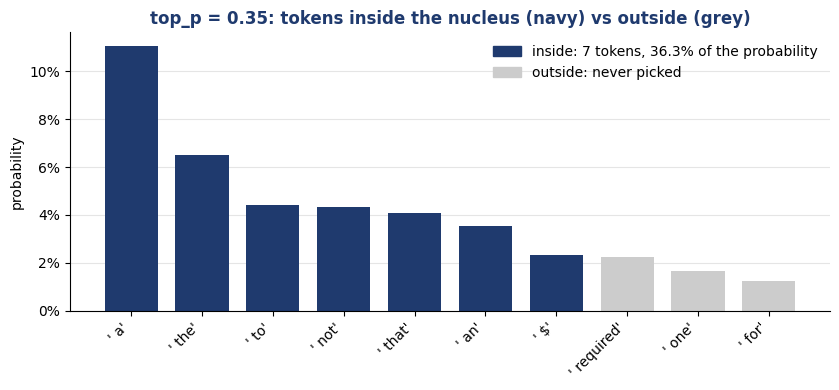

In [9]:
if not GPT2_READY:
    print(SKIPPED)
else:
    def nucleus(probs: torch.Tensor, p: float) -> tuple[int, float]:
        """The nucleus of top-p: the smallest set of most likely tokens whose probabilities add up to at
        least p, including the token that crosses p. Returns its size and the probability it holds."""
        cumulative = torch.cumsum(torch.sort(probs, descending=True).values, dim=-1)
        size = int((cumulative < p).sum().item()) + 1  # the tokens below p, plus the one that reaches it
        return size, cumulative[size - 1].item()

    for p in [0.35, 0.5, 0.9]:
        size, held = nucleus(probabilities, p)
        print(f"top_p = {p}: the nucleus is the {size:,} most likely tokens, holding {held:.1%} of the probability")

    TOP_P = 0.35  # low, so that the cut falls inside the top ten; values near 0.9 are more usual
    size, held = nucleus(probabilities, TOP_P)
    fig, ax = plot_top10([NAVY if rank < size else GREY for rank in range(10)],
                         f"top_p = {TOP_P}: tokens inside the nucleus (navy) vs outside (grey)")
    ax.legend(handles=[Patch(color=NAVY, label=f"inside: {size} tokens, {held:.1%} of the probability"),
                       Patch(color=GREY, label="outside: never picked")], frameon=False)
    fig.tight_layout()
    plt.show()

At `top_p = 0.35` the nucleus is seven tokens, which hold 36.3% of the probability. The six favourites together stay below 35%, so the seventh, `' $'`, is the token that crosses *p*, and it is kept. At `top_p = 0.9`, the value you are more likely to meet in practice, GPT-2 still keeps 1,010 candidates after this prompt — a measure of how unsure it is. A model that knew more would concentrate the probability on far fewer tokens.

### 3.4 Greedy, sampled and too hot

**Greedy** decoding always takes the favourite; there is no randomness at all. **Sampling** draws the next token at random from the reshaped distribution. The cell continues the prompt of the slide "GPT-2 small vs. Frontier Model" by 40 tokens, three times, from the same seed; only the picking rule changes. Whenever it samples, `transformers` also applies `top_k=50` by default, which keeps only the 50 favourites. We write that setting out, so that nothing is hidden, and switch it off with `top_k=0` in the too-hot run. Because every run starts from the same seed, rerunning the cell with the same versions of `torch` and `transformers` gives the same three texts. The saved outputs come from torch 2.7.0 and transformers 4.48.2, as the first code cell of this section printed; torch 2.12.0 with transformers 5.10.2 gave the same texts, and other versions may give different ones.

In [10]:
if not GPT2_READY:
    print(SKIPPED)
else:
    encoded = gpt2_tokenizer("An actuary's main job is to", return_tensors="pt")

    def continue_text(**picking) -> str:
        """Continue the prompt by 40 tokens under one picking rule, starting from the same seed every time."""
        set_seed(SEED)  # seeds Python, NumPy and torch, so that each run draws the same random numbers
        output = gpt2.generate(**encoded, max_new_tokens=40, pad_token_id=gpt2_tokenizer.eos_token_id, **picking)
        return gpt2_tokenizer.decode(output[0], skip_special_tokens=True)

    RUNS = [
        ("GREEDY", dict(do_sample=False)),
        ("SAMPLED", dict(do_sample=True, temperature=1.0, top_p=0.9, top_k=50)),
        ("SAMPLED, too hot", dict(do_sample=True, temperature=1.5, top_p=1.0, top_k=0)),
    ]
    generations = {}
    for name, picking in RUNS:
        generations[name] = continue_text(**picking)
        settings = ", ".join(f"{key}={value}" for key, value in picking.items())
        print(f"--- {name} ({settings})")
        print(generations[name])
        print()

--- GREEDY (do_sample=False)
An actuary's main job is to make sure that the person is well-informed about the subject matter of the work.

The actuary's main job is to make sure that the person is well-informed about the subject matter

--- SAMPLED (do_sample=True, temperature=1.0, top_p=0.9, top_k=50)
An actuary's main job is to record and analyze a deceased person's life. If someone is deceased, the funeral director would typically file it under a specific actuary's name.

The actuary's role includes conducting an analysis

--- SAMPLED, too hot (do_sample=True, temperature=1.5, top_p=1.0, top_k=0)
An actuary's main job is to record customers' meals, supplies in operating conversations, preparation, translating crucial dosages and talking rank berries. Its fuel fillettional makes ACHT an American casualty Sal Meielvedrone Park Alexandria



### What the three runs show

- **Greedy** is repeatable, and it loops: after one sentence it starts again with "The actuary's main job is to make sure that the person is well-informed about the subject matter". Deterministic is not the same as good.
- **Sampled, at `temperature=1.0`, `top_p=0.9` and `top_k=50`,** escapes the loop and stays fluent — and invents: an actuary who records "a deceased person's life", with a funeral director who files it "under a specific actuary's name".
- **Too hot, at `temperature=1.5` with no cut-off,** loses the thread within one sentence — "translating crucial dosages and talking rank berries" — and then produces words that are not words.

The greedy and the sampled text are the two on the slide "GPT-2 small vs. Frontier Model". Three lessons carry over to the hosted models. The dials reshape one probability distribution and nothing more. Turning them down buys repeatability, not correctness: greedy GPT-2 is repeatable *and* wrong. And what moves the probability onto the right tokens in the first place is a larger, better-trained model — the contrast on the same slide.

The GPT-5.4 model of this notebook runs the same loop on the provider's side, with a picking rule of its own. We leave its dials alone and look for consistency where it can be had: in `instructions`, in a schema (next notebook) and in checks of our own.

---

## 4 Tokens and cost, made visible

### Why it matters for actuaries

You are not billed per word, per question or per seat. You are billed per **token**, and separately for what you send and what comes back. Anyone who has to put a number in a business case needs to see the split once, on a sentence from their own world.

A token is a frequent chunk of text, not a word. Common words are one token; a name your tokeniser has never had much reason to learn is chopped into pieces. The two most actuarial words in the sentence below are exactly the ones that get chopped.

`tiktoken` cannot map our pinned model name to a tokeniser on its own, so we name the encoding ourselves: `o200k_base`, the family used by the current generation of OpenAI models. Its vocabulary has about 200,000 tokens, roughly four times GPT-2's 50,257 in section 3. The first run downloads the vocabulary, which takes a moment.

In [11]:
encoding = tiktoken.get_encoding("o200k_base")

sentence = "EIOPA published the Solvency II risk-free rate curve."
token_ids = encoding.encode(sentence)
pieces = [encoding.decode([i]) for i in token_ids]

print(f"{len(sentence.split())} words, but {len(token_ids)} tokens.")
print()
print(" | ".join(pieces))
print()
print(pieces)

8 words, but 14 tokens.

E | IO | PA |  published |  the |  Sol | v | ency |  II |  risk | -free |  rate |  curve | .

['E', 'IO', 'PA', ' published', ' the', ' Sol', 'v', 'ency', ' II', ' risk', '-free', ' rate', ' curve', '.']


Note the leading spaces: a space belongs to the token that follows it. And note where the splits fall — that is the tokeniser's vocabulary, not the English language.

Now the price of one real call. `usage` comes back with every reply, and the two constants from section 1 turn it into money.

In [12]:
answer = ask("In one sentence: what is the risk margin under Solvency II?")
usage = last_response.usage

cost_in = usage.input_tokens / 1_000_000 * PRICE_IN_USD_PER_MTOK
cost_out = usage.output_tokens / 1_000_000 * PRICE_OUT_USD_PER_MTOK

print(answer)
print()
print(f"input tokens  : {usage.input_tokens:>5}  ->  USD {cost_in:.6f}")
print(f"output tokens : {usage.output_tokens:>5}  ->  USD {cost_out:.6f}")
print(f"total         : {usage.total_tokens:>5}  ->  USD {cost_in + cost_out:.6f}")
print()
print(f"10,000 calls like this one: about USD {(cost_in + cost_out) * 10_000:.2f}.")
print("Prices: list price as of 15 September 2026.")

Under Solvency II, the risk margin is an additional amount added to the best estimate to reflect the cost of providing the eligible capital needed to take over and run the insurance obligations, ensuring a prudent valuation of technical provisions.

input tokens  :    21  ->  USD 0.000004
output tokens :    49  ->  USD 0.000061
total         :    70  ->  USD 0.000065

10,000 calls like this one: about USD 0.65.
Prices: list price as of 15 September 2026.


---

## 5 Prompt engineering on one claim note

### Why it matters for actuaries

Claims triage, cause-of-loss coding, complaint routing: the task is nearly always *turn a sentence a human wrote into a category an actuary can count*. The prompt is what decides whether that category is usable. Three techniques from the slides, run against one real note, in the order you should try them.

In [13]:
NOTE = "Rear-ended at a red light; the other driver admitted fault. Bumper and tailgate dented."

print(NOTE)

Rear-ended at a red light; the other driver admitted fault. Bumper and tailgate dented.


**Zero-shot** — you describe the task and nothing else. Always start here; it is the cheapest prompt there is.

In [14]:
zero_shot = f"""Claim note: "{NOTE}"

Give the cause of loss as one category."""

print(ask(zero_shot))

**Cause of loss:** Motor Vehicle Accident (Rear-End Collision)


**Few-shot** — you show the task instead of describing it. Two worked examples are usually enough to communicate a label set and a format that a paragraph of instructions would struggle to pin down.

In [15]:
few_shot = f"""Classify the cause of loss of a motor claim note.

"Hail dented the roof." -> weather
"Car gone overnight." -> theft
"{NOTE}" ->"""

print(ask(few_shot))

For: “Rear-ended at a red light; the other driver admitted fault. Bumper and tailgate dented.”

**Classification: accident (collision / driver fault).**


**Chain-of-thought** — you ask for the reasoning before the answer. It costs more output tokens, and it buys you something an audit file cares about: a visible argument you can disagree with.

In [16]:
chain_of_thought = f"""Claim note: "{NOTE}"

Reason step by step about the cause of loss, then end with a line in exactly this form:
Cause: <category>"""

print(ask(chain_of_thought))

The note describes a car accident that occurred when the claimant was rear-ended at a red light.  
Because the other driver admitted fault, the initiating event is the other driver’s negligent operation of the vehicle (rear-end collision while stopped).  
The resulting damage is limited to the claimant’s vehicle—specifically the bumper and tailgate being dented—indicating impact-related property damage rather than loss from a different peril (e.g., theft, fire, weather).  
Therefore, the loss is caused by a traffic collision due to another party’s fault.

Cause: Auto accident (rear-end collision)


### What actually differed

All three got the substance right: a rear-end collision, another driver at fault, a motor accident. On a note this clear that is the easy part. What differed was the **shape** of the answer and what it cost.

- **Zero-shot** returned `**Cause of loss:** Motor Vehicle Accident (Rear-End Collision)` — correct, but in a vocabulary the model chose for itself, with its own bold formatting.
- **Few-shot** returned `**Classification: accident (collision / driver fault).**` — the two examples pulled it towards their lower-case, one-word style, and "accident" sits in the same register as "weather" and "theft". But it did *not* copy the bare `-> label` format: it still wrapped the label in a line of prose.
- **Chain-of-thought** wrote four sentences of reasoning — stopped at a red light, other driver admitted fault, damage consistent with impact rather than theft, fire or weather — and then obeyed the final-line instruction exactly: `Cause: Auto accident (rear-end collision)`. It was by far the most expensive of the three in output tokens, and by far the easiest to check.

The honest conclusion: examples steer vocabulary, an explicit format instruction steers format, and reasoning buys you an argument you can disagree with. But **none of the three returned a value you could write straight into a database column** without tidying it up first. Prompting can ask nicely; it cannot guarantee. Closing that gap is exactly what structured outputs do, and that is the next notebook.

---

## 6 Limitations, demonstrated rather than asserted

### Why it matters for actuaries

The slides listed the limitations. A list is easy to nod at and easy to forget. Three short live demonstrations follow, and each one ends with the only thing that matters: what you do about it.

### 6.1 Hallucination

A model is trained to produce text that *sounds* like the right answer, so when we ask about an article of the Solvency II Directive that does not exist, there is nothing in its training to stop it answering anyway.

In [17]:
print(ask("Summarise what Article 247b of the Solvency II Directive (2009/138/EC) requires of insurers."))

Article **247b** of Directive **2009/138/EC (Solvency II)** sets out requirements for how insurers **must calculate and present information relating to the group’s solvency needs and capital position**, in particular by requiring that the **administrative or management body** (and related governance function) ensure that the **group solvency position** is **properly determined and reported** in accordance with the Directive.

In practical terms, it requires insurers (where the rule applies—typically in a **group** context) to ensure that:

- **Solvency information for the group** is calculated in line with Solvency II rules (including the relevant group methods/approach);
- The information provided to the supervisor is **complete, accurate and consistent** with the group’s solvency situation; and
- The insurer has **governance/accountability arrangements** so that the body responsible for administration/management can demonstrate compliance.

If you want, tell me whether you need this 

There is no Article 247b in Directive 2009/138/EC. The model nevertheless produced a fluent, confident, well-formatted summary — bold text, a three-point bulleted list of what insurers "must" do, a sentence placing the rule in a group-supervision context — and **offered no warning at all** that the article might not exist. It closed by asking which member state we meant.

Nothing in the tone of that answer distinguishes it from a correct one. Re-run the cell and you may get a hedge instead: the model is not deterministic, and that unreliability is itself the point.

**What to do about it:** never let a model be your source for a legal, regulatory or numerical citation. Check every reference against the primary text, or supply the text yourself and ask the model to work only from what you gave it.

### 6.2 Prompt sensitivity

The two prompts below ask the same thing about the same claim note, differing only in word order, so any difference in the answers comes from the wording and not from the question.

In [18]:
wordings = [
    'One word: cause of loss for "Pipe burst in the flat above and soaked our ceiling."',
    'Cause of loss, one word: "Pipe burst in the flat above and soaked our ceiling."',
]

for wording in wordings:
    print(f"prompt: {wording}")
    print(f"answer: {ask(wording)}")
    print()

prompt: One word: cause of loss for "Pipe burst in the flat above and soaked our ceiling."


answer: Waterlogging

prompt: Cause of loss, one word: "Pipe burst in the flat above and soaked our ceiling."


answer: Plumbing leak.



Two prompts with the same words in a different order, and two different answers: **"Waterlogging"** and **"Plumbing leak."** Neither is a cause-of-loss code any insurer uses, and the two would land in different buckets in any downstream count.

**What to do about it:** fix the wording, keep it under version control like any other business rule, give the model a closed list of the categories you actually use, and test the prompt on a sample of notes before you trust it on a portfolio.

### 6.3 The training cut-off

A model knows nothing that was published after its training data was assembled, and a figure that moves every month is the clearest case of all.

In [19]:
print(ask("What was the 10-year euro risk-free spot rate in EIOPA's published "
          "term structure for end-August 2026?"))

I don’t have access to EIOPA’s specific “term structure” publication history in this chat, so I can’t reliably quote the exact **10-year euro risk‑free spot rate for end‑August 2026** without the source document or a link.

If you share the EIOPA table (or a link / screenshot) for **end‑August 2026**, I can read it and tell you the exact **10‑year** spot rate value.


This one **behaved well**: the model declined, said plainly that it could not reliably quote the figure, and asked for the source. That is the right answer, and it would be dishonest to pretend otherwise.

Note what that does *not* prove. The same model, two cells above, invented an article of the Solvency II Directive rather than admitting it did not know. Declining is a behaviour the model sometimes has, not a guarantee you can rely on — and a rate that moves monthly is the easiest case for it to spot.

**What to do about it:** anything time-sensitive comes from you, not from the model. Paste the current figure into the prompt, or retrieve it from a source you control.

---

## 7 Summary and what comes next

With one helper, a few lines of code per step and well under a cent of API spend, you have done every practical thing the slides described:

- **One helper, one model constant.** Every API call in this notebook went through `ask()` against a pinned model, so what changed between cells was always the prompt, never the plumbing.
- **The parameters you actually control.** `instructions` changed the audience and therefore the answer; `max_output_tokens` cut the answer off and flagged itself as `incomplete`. `temperature` and `top_p` stayed out of every API call, on purpose.
- **The picking step, opened up.** On GPT-2 small, the favourite after "The Solvency Capital Requirement is" was `' a'` at 11.1%; temperature 0.5 lifted it to 47.2%, `top_p = 0.9` still left 1,010 candidates, greedy decoding looped, and sampling invented a funeral director. The dials change how a token is picked, not what the model knows.
- **Tokens, not words.** Eight words became fourteen tokens, with `EIOPA` split into `E | IO | PA` and `Solvency` into `Sol | v | ency`. A real call came back with its own `usage`, which turned into a real price: roughly USD 0.65 for ten thousand calls like it, at the list price of 15 September 2026.
- **Three prompting techniques on one claim note.** They agreed on the substance and disagreed on the shape, and none of them produced a value fit for a database column.
- **Three limitations, live.** A confidently invented article of the Solvency II Directive; two near-identical prompts giving "Waterlogging" and "Plumbing leak."; and one honest refusal on a figure the model could not know.

The thread running through all of it: a model will give you an answer. Making that answer *usable* — a fixed schema, a real calculation, a model tuned to your own wording — is engineering, not prompting.

**Next notebook:** `02_llm_techniques`.